# Exploratory Data Analysis (EDA) Profundo - Dataset Curves

## Parte 2: Analisis Estadistico Detallado

Este notebook profundiza en las estadisticas de las coordenadas, distribuciones, y caracteristicas numericas de las curvas.

---

### Tabla de Contenidos
1. Carga de Datos
2. Estadisticas de Coordenadas TARGET
3. Estadisticas de Coordenadas PIXEL_CURVES
4. Analisis de Distribucion
5. Correlaciones y Relaciones
6. Analisis del Parametro X
7. Comparativas Target vs Pixel

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import re
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuracion
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [14, 6]
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', None)

# Rutas
BASE_PATH = Path('..')
PIXEL_CURVES_PATH = BASE_PATH / 'datos' / 'pixel_curves'
TARGET_PATH = BASE_PATH / 'datos' / 'target'

print("Librerias cargadas correctamente")

Librerias cargadas correctamente


---
## 1. Carga de Datos

In [2]:
def load_target_curve(curve_id):
    """Carga una curva target."""
    filepath = TARGET_PATH / f'curve_{curve_id:04d}.txt'
    data = np.loadtxt(filepath, delimiter=',')
    return data[:, 0], data[:, 1]  # X, Y

def load_pixel_curve(curve_id, x_value):
    """Carga una curva pixelizada."""
    filepath = PIXEL_CURVES_PATH / f'curve_{curve_id:04d}_X{x_value}.txt'
    data = np.loadtxt(filepath)
    return data[:, 0], data[:, 1]  # X, Y

# Cargar todas las curvas target para analisis estadistico
print("Cargando datos de curvas target...")
target_data = {}
for i in range(1, 501):
    x, y = load_target_curve(i)
    target_data[i] = {'x': x, 'y': y}
print(f"Curvas target cargadas: {len(target_data)}")

# Cargar muestra de curvas pixel para analisis
print("\nCargando datos de curvas pixel...")
pixel_data = defaultdict(dict)
x_values = [10, 15, 18, 21, 25]

for x_val in x_values:
    for i in range(1, 501):
        px, py = load_pixel_curve(i, x_val)
        pixel_data[x_val][i] = {'x': px, 'y': py}
print(f"Curvas pixel cargadas por variante: {sum(len(pixel_data[x]) for x in x_values)}")

Cargando datos de curvas target...
Curvas target cargadas: 500

Cargando datos de curvas pixel...
Curvas pixel cargadas por variante: 2500


---
## 2. Estadisticas de Coordenadas TARGET

In [3]:
print("ESTADISTICAS GLOBALES DE CURVAS TARGET")
print("=" * 70)

# Recopilar estadisticas por curva
target_stats = []

for curve_id, data in target_data.items():
    x, y = data['x'], data['y']
    stats_dict = {
        'curve_id': curve_id,
        'n_points': len(x),
        'x_min': x.min(),
        'x_max': x.max(),
        'x_mean': x.mean(),
        'x_std': x.std(),
        'x_range': x.max() - x.min(),
        'y_min': y.min(),
        'y_max': y.max(),
        'y_mean': y.mean(),
        'y_std': y.std(),
        'y_range': y.max() - y.min(),
        'x_median': np.median(x),
        'y_median': np.median(y),
        'x_q25': np.percentile(x, 25),
        'x_q75': np.percentile(x, 75),
        'y_q25': np.percentile(y, 25),
        'y_q75': np.percentile(y, 75)
    }
    target_stats.append(stats_dict)

df_target_stats = pd.DataFrame(target_stats)
print("\nEstadisticas por curva (primeras 10):")
print(df_target_stats.head(10).to_string())

ESTADISTICAS GLOBALES DE CURVAS TARGET

Estadisticas por curva (primeras 10):
   curve_id  n_points      x_min       x_max      x_mean      x_std     x_range      y_min      y_max     y_mean      y_std    y_range    x_median   y_median       x_q25       x_q75      y_q25      y_q75
0         1      8000  17.884691  356.814517  183.186474  94.781747  338.929825   0.738733  76.645238  57.804290  15.897773  75.906505  186.908795  62.844786  100.276892  259.804973  50.984578  68.831524
1         2      8000   6.679459  283.478899  152.965788  76.105628  276.799440  30.907029  92.557243  67.815892  14.747721  61.650214  163.426763  71.819771   89.767238  209.889479  58.702788  76.178831
2         3      8000   6.502006  219.074899  106.487170  59.612875  212.572893  30.598331  96.221128  69.296372  21.519132  65.622797   98.820252  79.420784   57.231623  156.697497  49.094506  86.981580
3         4      8000   6.589477  106.812164   58.148063  28.087620  100.222687  41.837166  93.717057  62.

In [4]:
# Resumen estadistico global
print("\nRESUMEN ESTADISTICO GLOBAL - COORDENADA X")
print("-" * 50)
x_cols = ['x_min', 'x_max', 'x_mean', 'x_std', 'x_range']
print(df_target_stats[x_cols].describe().round(4).to_string())


RESUMEN ESTADISTICO GLOBAL - COORDENADA X
--------------------------------------------------
          x_min     x_max    x_mean     x_std   x_range
count  500.0000  500.0000  500.0000  500.0000  500.0000
mean     9.9699  196.5482  103.0590   54.0572  186.5783
std      4.7812   77.9369   39.8893   22.7073   77.6094
min      2.8779   42.7323   24.3256   10.7637   37.3320
25%      5.5987  132.3963   68.9332   35.6337  124.7843
50%      9.3181  199.0302  103.0231   55.0952  189.7042
75%     13.9295  259.5319  137.5125   73.4080  250.9774
max     20.3084  356.8145  196.4780  103.4664  342.6961


In [5]:
print("\nRESUMEN ESTADISTICO GLOBAL - COORDENADA Y")
print("-" * 50)
y_cols = ['y_min', 'y_max', 'y_mean', 'y_std', 'y_range']
print(df_target_stats[y_cols].describe().round(4).to_string())


RESUMEN ESTADISTICO GLOBAL - COORDENADA Y
--------------------------------------------------
          y_min     y_max    y_mean     y_std   y_range
count  500.0000  500.0000  500.0000  500.0000  500.0000
mean    19.1326   79.1176   56.4165   15.1420   59.9850
std     11.4425   12.7512    9.7285    4.4910   16.6738
min      0.0143   36.9415   26.2808    1.6321    7.7366
25%      9.0845   71.1442   50.4520   12.0279   49.1842
50%     19.3867   80.0013   57.6705   14.9732   59.0091
75%     28.9485   88.3681   63.0609   18.0453   71.8325
max     43.0758  110.9097   79.7463   30.1117  110.8954


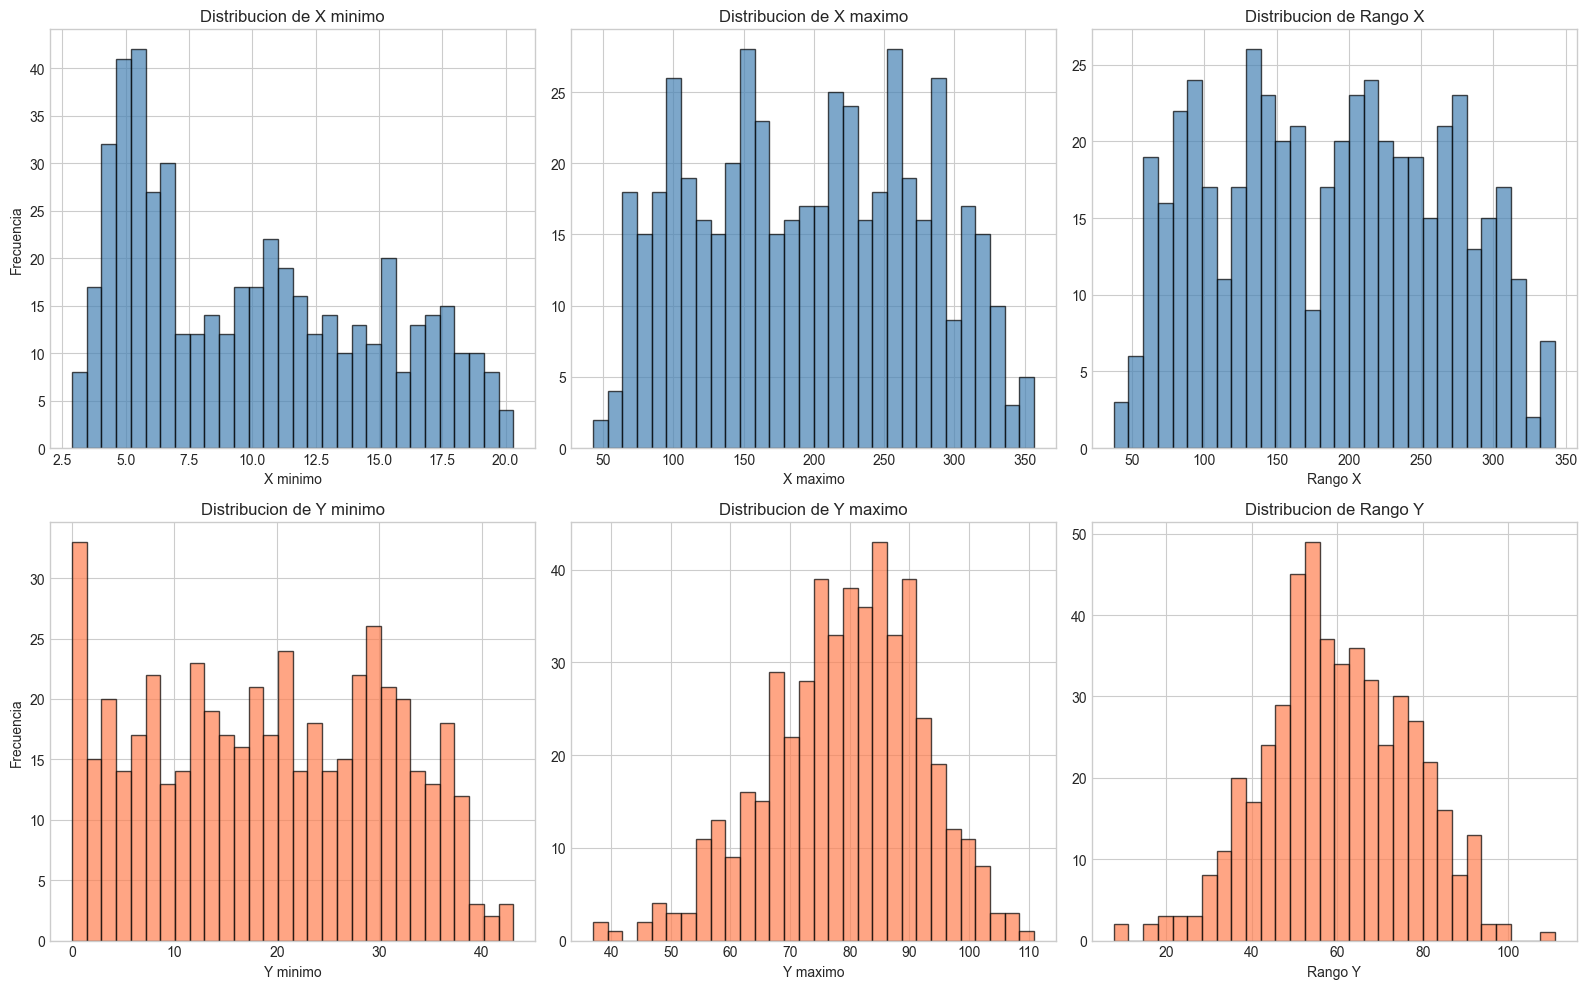

In [6]:
# Visualizacion de distribuciones
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Distribucion de X minimo
axes[0, 0].hist(df_target_stats['x_min'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_title('Distribucion de X minimo')
axes[0, 0].set_xlabel('X minimo')
axes[0, 0].set_ylabel('Frecuencia')

# Distribucion de X maximo
axes[0, 1].hist(df_target_stats['x_max'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 1].set_title('Distribucion de X maximo')
axes[0, 1].set_xlabel('X maximo')

# Distribucion de rango X
axes[0, 2].hist(df_target_stats['x_range'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 2].set_title('Distribucion de Rango X')
axes[0, 2].set_xlabel('Rango X')

# Distribucion de Y minimo
axes[1, 0].hist(df_target_stats['y_min'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1, 0].set_title('Distribucion de Y minimo')
axes[1, 0].set_xlabel('Y minimo')
axes[1, 0].set_ylabel('Frecuencia')

# Distribucion de Y maximo
axes[1, 1].hist(df_target_stats['y_max'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1, 1].set_title('Distribucion de Y maximo')
axes[1, 1].set_xlabel('Y maximo')

# Distribucion de rango Y
axes[1, 2].hist(df_target_stats['y_range'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1, 2].set_title('Distribucion de Rango Y')
axes[1, 2].set_xlabel('Rango Y')

plt.tight_layout()
plt.savefig('distribuciones_target.png', dpi=150, bbox_inches='tight')
plt.show()

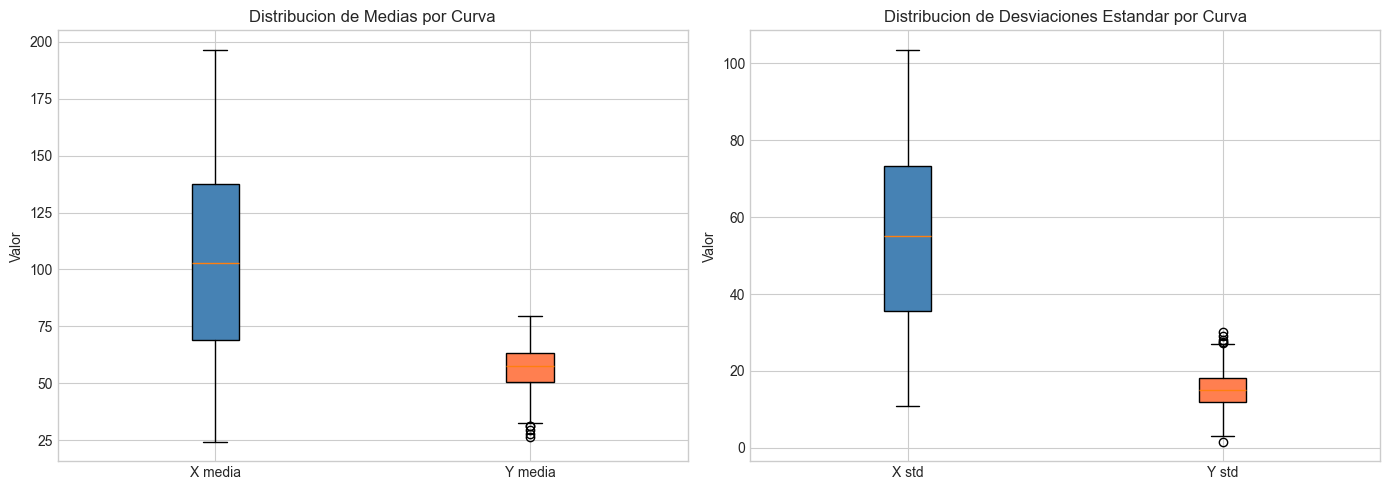

In [7]:
# Boxplots de estadisticas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot de medias
box_data = [df_target_stats['x_mean'], df_target_stats['y_mean']]
bp1 = axes[0].boxplot(box_data, labels=['X media', 'Y media'], patch_artist=True)
bp1['boxes'][0].set_facecolor('steelblue')
bp1['boxes'][1].set_facecolor('coral')
axes[0].set_title('Distribucion de Medias por Curva')
axes[0].set_ylabel('Valor')

# Boxplot de desviaciones estandar
box_data2 = [df_target_stats['x_std'], df_target_stats['y_std']]
bp2 = axes[1].boxplot(box_data2, labels=['X std', 'Y std'], patch_artist=True)
bp2['boxes'][0].set_facecolor('steelblue')
bp2['boxes'][1].set_facecolor('coral')
axes[1].set_title('Distribucion de Desviaciones Estandar por Curva')
axes[1].set_ylabel('Valor')

plt.tight_layout()
plt.savefig('boxplots_target.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Estadisticas de Coordenadas PIXEL_CURVES

In [8]:
print("ESTADISTICAS GLOBALES DE CURVAS PIXEL")
print("=" * 70)

# Recopilar estadisticas por variante X
pixel_stats_by_x = {}

for x_val in x_values:
    stats_list = []
    for curve_id, data in pixel_data[x_val].items():
        x, y = data['x'], data['y']
        stats_dict = {
            'curve_id': curve_id,
            'x_variant': x_val,
            'n_points': len(x),
            'x_min': x.min(),
            'x_max': x.max(),
            'x_mean': x.mean(),
            'x_std': x.std(),
            'x_range': x.max() - x.min(),
            'y_min': y.min(),
            'y_max': y.max(),
            'y_mean': y.mean(),
            'y_std': y.std(),
            'y_range': y.max() - y.min()
        }
        stats_list.append(stats_dict)
    pixel_stats_by_x[x_val] = pd.DataFrame(stats_list)
    print(f"\nVariante X{x_val}: {len(stats_list)} curvas procesadas")

ESTADISTICAS GLOBALES DE CURVAS PIXEL

Variante X10: 500 curvas procesadas

Variante X15: 500 curvas procesadas

Variante X18: 500 curvas procesadas

Variante X21: 500 curvas procesadas

Variante X25: 500 curvas procesadas


In [9]:
# Resumen por variante X
print("\nCOMPARATIVA DE ESTADISTICAS POR VARIANTE X")
print("=" * 80)

summary_data = []
for x_val in x_values:
    df = pixel_stats_by_x[x_val]
    summary_data.append({
        'Variante': f'X{x_val}',
        'Puntos_Mean': df['n_points'].mean(),
        'Puntos_Std': df['n_points'].std(),
        'X_Min_Mean': df['x_min'].mean(),
        'X_Max_Mean': df['x_max'].mean(),
        'X_Range_Mean': df['x_range'].mean(),
        'Y_Min_Mean': df['y_min'].mean(),
        'Y_Max_Mean': df['y_max'].mean(),
        'Y_Range_Mean': df['y_range'].mean()
    })

df_summary = pd.DataFrame(summary_data)
print(df_summary.round(2).to_string(index=False))


COMPARATIVA DE ESTADISTICAS POR VARIANTE X
Variante  Puntos_Mean  Puntos_Std  X_Min_Mean  X_Max_Mean  X_Range_Mean  Y_Min_Mean  Y_Max_Mean  Y_Range_Mean
     X10       201.73       80.65        9.98      196.55        186.57       19.14       79.10         59.96
     X15       302.25      120.95       15.45      295.31        279.87       29.21      119.16         89.94
     X18       362.53      145.18       18.78      354.59        335.81       35.26      143.21        107.95
     X21       422.85      169.38       22.04      413.86        391.81       41.27      167.24        125.98
     X25       503.24      201.67       26.42      492.86        466.44       49.32      199.30        149.98


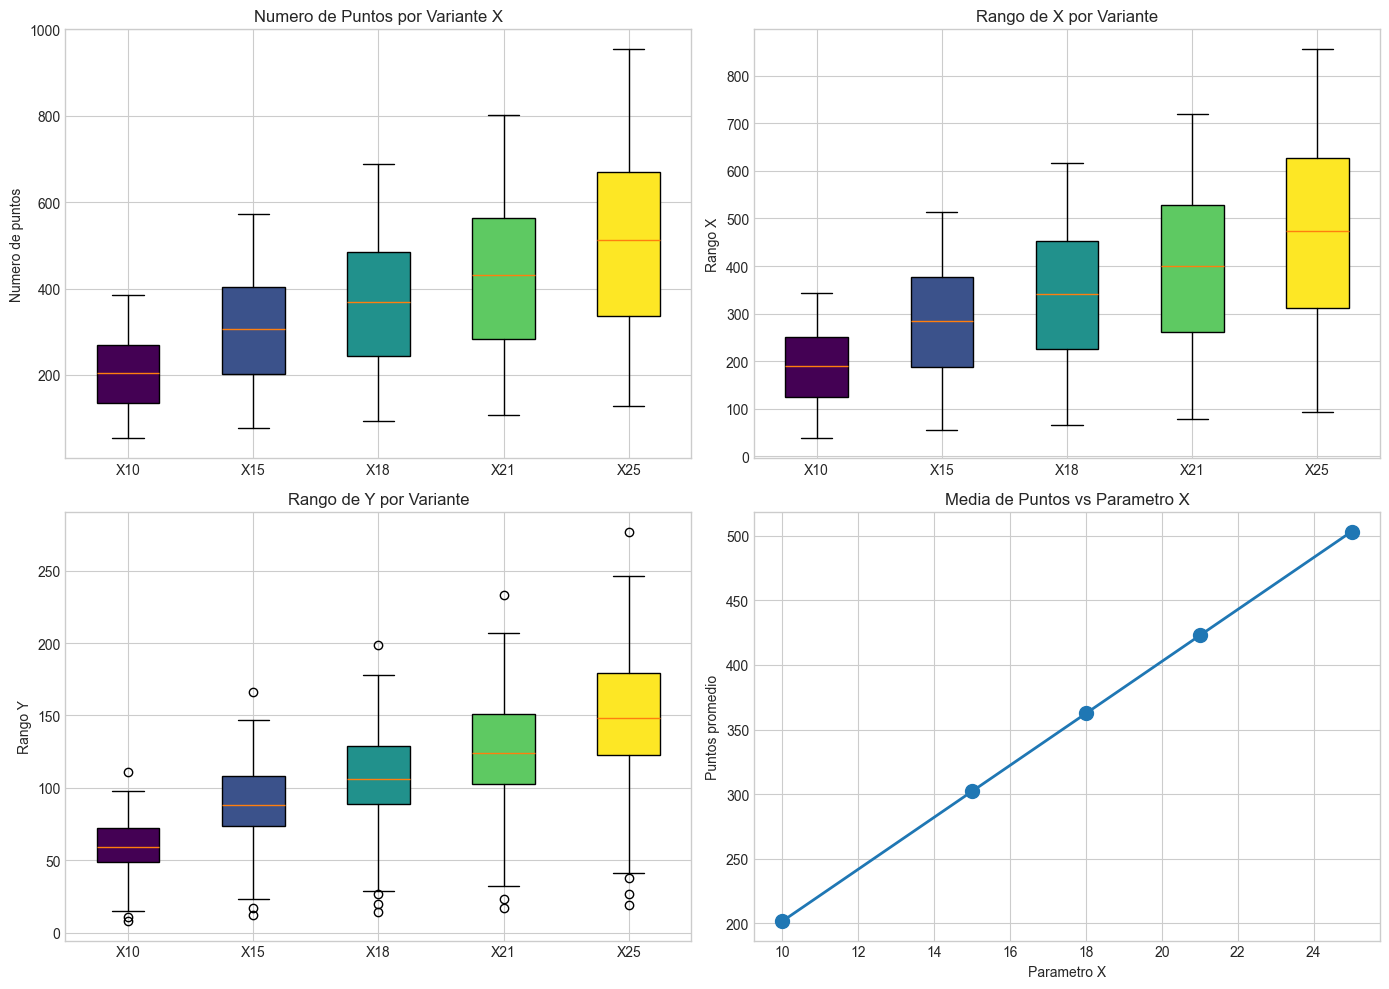

In [10]:
# Visualizacion comparativa
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Numero de puntos por variante
data_points = [pixel_stats_by_x[x]['n_points'] for x in x_values]
bp1 = axes[0, 0].boxplot(data_points, labels=[f'X{x}' for x in x_values], patch_artist=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(x_values)))
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
axes[0, 0].set_title('Numero de Puntos por Variante X')
axes[0, 0].set_ylabel('Numero de puntos')

# Rango X por variante
data_x_range = [pixel_stats_by_x[x]['x_range'] for x in x_values]
bp2 = axes[0, 1].boxplot(data_x_range, labels=[f'X{x}' for x in x_values], patch_artist=True)
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
axes[0, 1].set_title('Rango de X por Variante')
axes[0, 1].set_ylabel('Rango X')

# Rango Y por variante
data_y_range = [pixel_stats_by_x[x]['y_range'] for x in x_values]
bp3 = axes[1, 0].boxplot(data_y_range, labels=[f'X{x}' for x in x_values], patch_artist=True)
for patch, color in zip(bp3['boxes'], colors):
    patch.set_facecolor(color)
axes[1, 0].set_title('Rango de Y por Variante')
axes[1, 0].set_ylabel('Rango Y')

# Evolucion de medias por variante
means_points = [np.mean(pixel_stats_by_x[x]['n_points']) for x in x_values]
axes[1, 1].plot(x_values, means_points, 'o-', linewidth=2, markersize=10)
axes[1, 1].set_title('Media de Puntos vs Parametro X')
axes[1, 1].set_xlabel('Parametro X')
axes[1, 1].set_ylabel('Puntos promedio')
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('estadisticas_pixel_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Analisis de Distribucion

In [11]:
print("ANALISIS DE DISTRIBUCIONES")
print("=" * 70)

# Combinar todos los puntos target para analisis global
all_x_target = np.concatenate([target_data[i]['x'] for i in target_data])
all_y_target = np.concatenate([target_data[i]['y'] for i in target_data])

print(f"\nTotal de puntos target: {len(all_x_target):,}")
print(f"\nEstadisticas globales de X (target):")
print(f"  Media: {all_x_target.mean():.4f}")
print(f"  Mediana: {np.median(all_x_target):.4f}")
print(f"  Std: {all_x_target.std():.4f}")
print(f"  Min: {all_x_target.min():.4f}")
print(f"  Max: {all_x_target.max():.4f}")
print(f"  Skewness: {stats.skew(all_x_target):.4f}")
print(f"  Kurtosis: {stats.kurtosis(all_x_target):.4f}")

ANALISIS DE DISTRIBUCIONES

Total de puntos target: 4,000,000

Estadisticas globales de X (target):
  Media: 103.0590
  Mediana: 86.5245
  Std: 70.8854
  Min: 2.8779
  Max: 356.8145
  Skewness: 0.8151
  Kurtosis: -0.0532


In [12]:
print(f"\nEstadisticas globales de Y (target):")
print(f"  Media: {all_y_target.mean():.4f}")
print(f"  Mediana: {np.median(all_y_target):.4f}")
print(f"  Std: {all_y_target.std():.4f}")
print(f"  Min: {all_y_target.min():.4f}")
print(f"  Max: {all_y_target.max():.4f}")
print(f"  Skewness: {stats.skew(all_y_target):.4f}")
print(f"  Kurtosis: {stats.kurtosis(all_y_target):.4f}")


Estadisticas globales de Y (target):
  Media: 56.4165
  Mediana: 57.7441
  Std: 18.5436
  Min: 0.0143
  Max: 110.9097
  Skewness: -0.3096
  Kurtosis: -0.2089


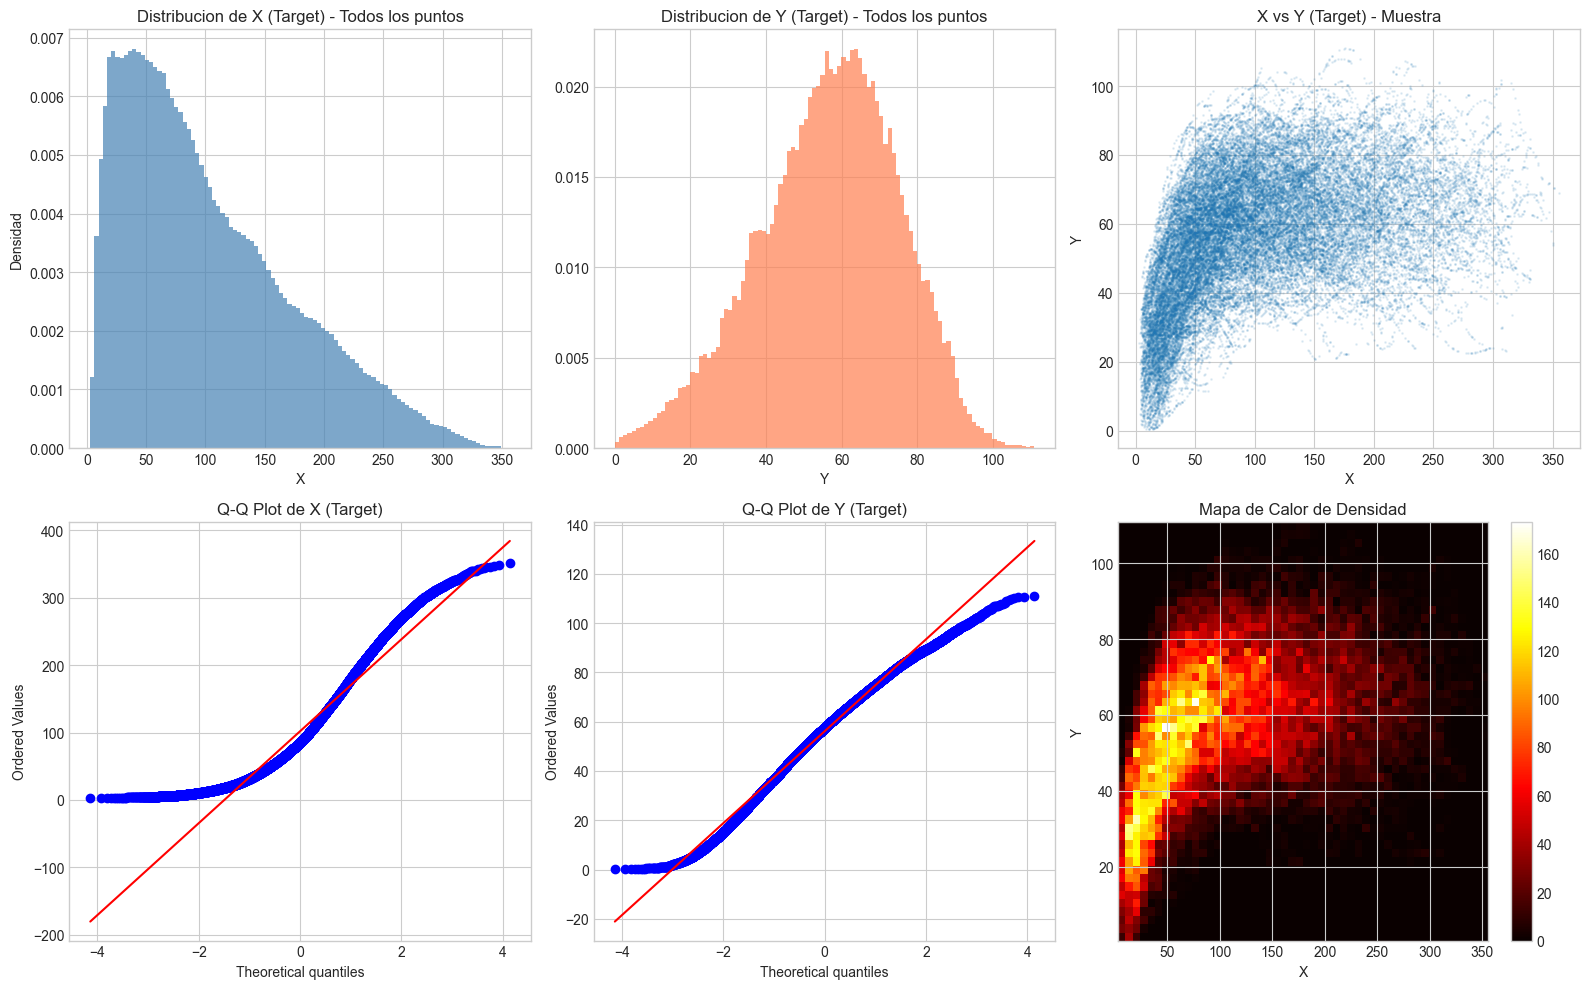

In [13]:
# Visualizacion de distribuciones globales
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Histograma de X target
axes[0, 0].hist(all_x_target, bins=100, edgecolor='none', alpha=0.7, color='steelblue', density=True)
axes[0, 0].set_title('Distribucion de X (Target) - Todos los puntos')
axes[0, 0].set_xlabel('X')
axes[0, 0].set_ylabel('Densidad')

# Histograma de Y target
axes[0, 1].hist(all_y_target, bins=100, edgecolor='none', alpha=0.7, color='coral', density=True)
axes[0, 1].set_title('Distribucion de Y (Target) - Todos los puntos')
axes[0, 1].set_xlabel('Y')

# Scatter X vs Y (muestra)
sample_size = 50000
indices = np.random.choice(len(all_x_target), size=min(sample_size, len(all_x_target)), replace=False)
axes[0, 2].scatter(all_x_target[indices], all_y_target[indices], alpha=0.1, s=1)
axes[0, 2].set_title('X vs Y (Target) - Muestra')
axes[0, 2].set_xlabel('X')
axes[0, 2].set_ylabel('Y')

# QQ-plots
stats.probplot(all_x_target[::100], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot de X (Target)')

stats.probplot(all_y_target[::100], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot de Y (Target)')

# Heatmap de densidad
h, xedges, yedges = np.histogram2d(all_x_target[indices], all_y_target[indices], bins=50)
im = axes[1, 2].imshow(h.T, origin='lower', aspect='auto', 
                       extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                       cmap='hot')
axes[1, 2].set_title('Mapa de Calor de Densidad')
axes[1, 2].set_xlabel('X')
axes[1, 2].set_ylabel('Y')
plt.colorbar(im, ax=axes[1, 2])

plt.tight_layout()
plt.savefig('distribuciones_globales.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Tests de normalidad (muestra)
print("\nTESTS DE NORMALIDAD (usando muestra de 5000 puntos)")
print("-" * 50)

sample_x = np.random.choice(all_x_target, size=5000, replace=False)
sample_y = np.random.choice(all_y_target, size=5000, replace=False)

# Shapiro-Wilk test
stat_x, p_x = stats.shapiro(sample_x)
stat_y, p_y = stats.shapiro(sample_y)

print(f"\nShapiro-Wilk Test para X:")
print(f"  Estadistico: {stat_x:.6f}")
print(f"  P-valor: {p_x:.6e}")
print(f"  Conclusion: {'Distribucion normal' if p_x > 0.05 else 'No es distribucion normal'}")

print(f"\nShapiro-Wilk Test para Y:")
print(f"  Estadistico: {stat_y:.6f}")
print(f"  P-valor: {p_y:.6e}")
print(f"  Conclusion: {'Distribucion normal' if p_y > 0.05 else 'No es distribucion normal'}")


TESTS DE NORMALIDAD (usando muestra de 5000 puntos)
--------------------------------------------------

Shapiro-Wilk Test para X:
  Estadistico: 0.935813
  P-valor: 4.831119e-42
  Conclusion: No es distribucion normal

Shapiro-Wilk Test para Y:
  Estadistico: 0.993062
  P-valor: 6.920350e-15
  Conclusion: No es distribucion normal


---
## 5. Correlaciones y Relaciones

In [15]:
print("ANALISIS DE CORRELACIONES")
print("=" * 70)

# Correlacion entre X e Y en target
correlations_per_curve = []
for curve_id, data in target_data.items():
    corr = np.corrcoef(data['x'], data['y'])[0, 1]
    correlations_per_curve.append({'curve_id': curve_id, 'correlation': corr})

df_corr = pd.DataFrame(correlations_per_curve)

print("\nCorrelacion X-Y por curva (Target):")
print(f"  Media: {df_corr['correlation'].mean():.4f}")
print(f"  Mediana: {df_corr['correlation'].median():.4f}")
print(f"  Std: {df_corr['correlation'].std():.4f}")
print(f"  Min: {df_corr['correlation'].min():.4f}")
print(f"  Max: {df_corr['correlation'].max():.4f}")

ANALISIS DE CORRELACIONES

Correlacion X-Y por curva (Target):
  Media: 0.5550
  Mediana: 0.6742
  Std: 0.3760
  Min: -0.6426
  Max: 0.9987


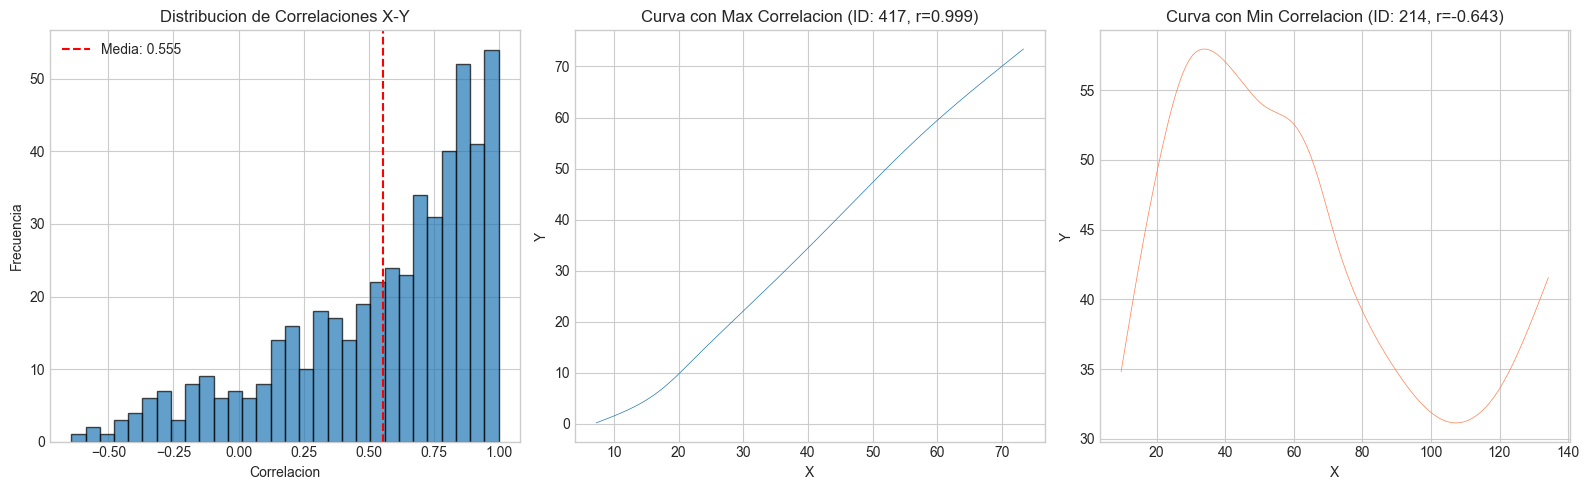

In [16]:
# Visualizacion de correlaciones
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histograma de correlaciones
axes[0].hist(df_corr['correlation'], bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(df_corr['correlation'].mean(), color='red', linestyle='--', label=f'Media: {df_corr["correlation"].mean():.3f}')
axes[0].set_title('Distribucion de Correlaciones X-Y')
axes[0].set_xlabel('Correlacion')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Curvas con mayor y menor correlacion
max_corr_id = df_corr.loc[df_corr['correlation'].idxmax(), 'curve_id']
min_corr_id = df_corr.loc[df_corr['correlation'].idxmin(), 'curve_id']

# Curva con maxima correlacion
x, y = target_data[max_corr_id]['x'], target_data[max_corr_id]['y']
axes[1].plot(x, y, linewidth=0.5)
axes[1].set_title(f'Curva con Max Correlacion (ID: {max_corr_id}, r={df_corr["correlation"].max():.3f})')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')

# Curva con minima correlacion
x, y = target_data[min_corr_id]['x'], target_data[min_corr_id]['y']
axes[2].plot(x, y, linewidth=0.5, color='coral')
axes[2].set_title(f'Curva con Min Correlacion (ID: {min_corr_id}, r={df_corr["correlation"].min():.3f})')
axes[2].set_xlabel('X')
axes[2].set_ylabel('Y')

plt.tight_layout()
plt.savefig('correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()


MATRIZ DE CORRELACION ENTRE ESTADISTICAS DE CURVAS
--------------------------------------------------


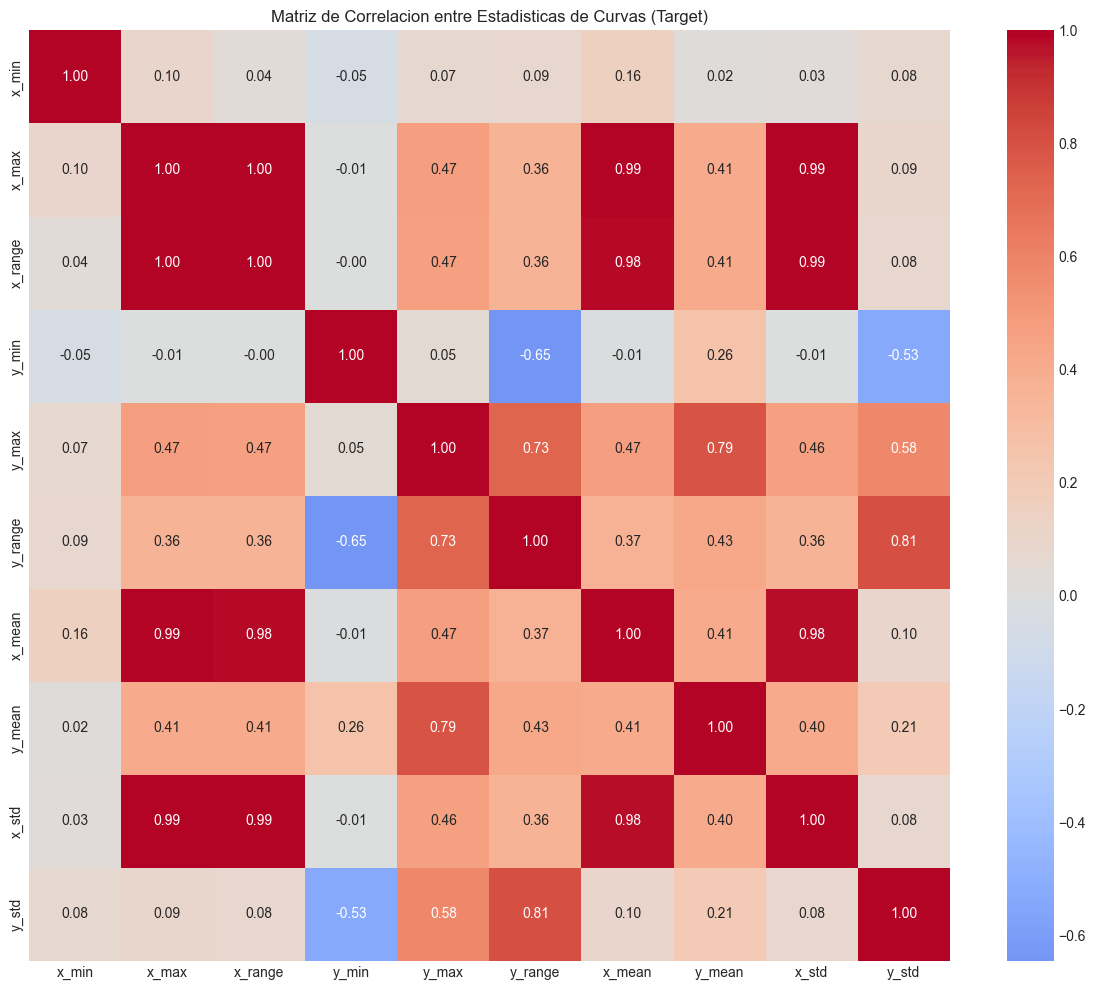

In [17]:
# Matriz de correlacion entre estadisticas de curvas
print("\nMATRIZ DE CORRELACION ENTRE ESTADISTICAS DE CURVAS")
print("-" * 50)

corr_cols = ['x_min', 'x_max', 'x_range', 'y_min', 'y_max', 'y_range', 'x_mean', 'y_mean', 'x_std', 'y_std']
corr_matrix = df_target_stats[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlacion entre Estadisticas de Curvas (Target)')
plt.tight_layout()
plt.savefig('matriz_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Analisis del Parametro X

In [18]:
print("ANALISIS DEL EFECTO DEL PARAMETRO X")
print("=" * 70)

# Calcular factor de escala
print("\nRelacion entre parametro X y numero de puntos:")
print("-" * 50)

for x_val in x_values:
    df = pixel_stats_by_x[x_val]
    mean_points = df['n_points'].mean()
    factor = mean_points / 8000 * 100  # Porcentaje respecto a target
    print(f"X{x_val}: {mean_points:.0f} puntos promedio ({factor:.1f}% del target)")

ANALISIS DEL EFECTO DEL PARAMETRO X

Relacion entre parametro X y numero de puntos:
--------------------------------------------------
X10: 202 puntos promedio (2.5% del target)
X15: 302 puntos promedio (3.8% del target)
X18: 363 puntos promedio (4.5% del target)
X21: 423 puntos promedio (5.3% del target)
X25: 503 puntos promedio (6.3% del target)


In [19]:
# Analisis de regresion: X vs puntos
mean_points_list = [pixel_stats_by_x[x]['n_points'].mean() for x in x_values]

# Regresion lineal
slope, intercept, r_value, p_value, std_err = stats.linregress(x_values, mean_points_list)

print(f"\nRegresion lineal (Puntos = a*X + b):")
print(f"  Pendiente (a): {slope:.4f}")
print(f"  Intercepto (b): {intercept:.4f}")
print(f"  R-cuadrado: {r_value**2:.4f}")
print(f"  P-valor: {p_value:.6e}")
print(f"  Ecuacion: Puntos = {slope:.2f} * X + {intercept:.2f}")


Regresion lineal (Puntos = a*X + b):
  Pendiente (a): 20.1010
  Intercepto (b): 0.7230
  R-cuadrado: 1.0000
  P-valor: 1.186826e-13
  Ecuacion: Puntos = 20.10 * X + 0.72


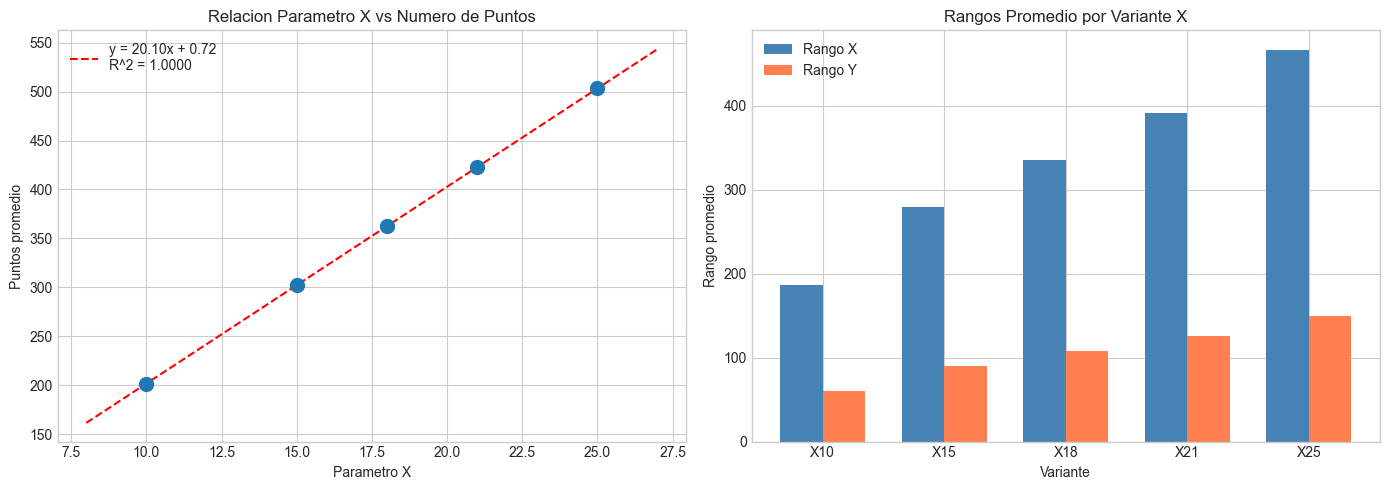

In [20]:
# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regresion
axes[0].scatter(x_values, mean_points_list, s=100, zorder=5)
x_line = np.linspace(8, 27, 100)
y_line = slope * x_line + intercept
axes[0].plot(x_line, y_line, 'r--', label=f'y = {slope:.2f}x + {intercept:.2f}\nR^2 = {r_value**2:.4f}')
axes[0].set_xlabel('Parametro X')
axes[0].set_ylabel('Puntos promedio')
axes[0].set_title('Relacion Parametro X vs Numero de Puntos')
axes[0].legend()
axes[0].grid(True)

# Comparativa de rangos
x_ranges = [pixel_stats_by_x[x]['x_range'].mean() for x in x_values]
y_ranges = [pixel_stats_by_x[x]['y_range'].mean() for x in x_values]

x_pos = np.arange(len(x_values))
width = 0.35

bars1 = axes[1].bar(x_pos - width/2, x_ranges, width, label='Rango X', color='steelblue')
bars2 = axes[1].bar(x_pos + width/2, y_ranges, width, label='Rango Y', color='coral')

axes[1].set_xlabel('Variante')
axes[1].set_ylabel('Rango promedio')
axes[1].set_title('Rangos Promedio por Variante X')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f'X{x}' for x in x_values])
axes[1].legend()

plt.tight_layout()
plt.savefig('parametro_x_analisis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Comparativa Target vs Pixel

In [21]:
print("COMPARATIVA TARGET vs PIXEL_CURVES")
print("=" * 70)

# Comparar estadisticas de la misma curva en diferentes formatos
comparison_data = []

for curve_id in range(1, 501):
    # Target stats
    t_x, t_y = target_data[curve_id]['x'], target_data[curve_id]['y']
    
    # Pixel stats para cada X
    for x_val in x_values:
        p_x, p_y = pixel_data[x_val][curve_id]['x'], pixel_data[x_val][curve_id]['y']
        
        comparison_data.append({
            'curve_id': curve_id,
            'x_variant': x_val,
            'target_x_min': t_x.min(),
            'target_x_max': t_x.max(),
            'pixel_x_min': p_x.min(),
            'pixel_x_max': p_x.max(),
            'target_y_min': t_y.min(),
            'target_y_max': t_y.max(),
            'pixel_y_min': p_y.min(),
            'pixel_y_max': p_y.max(),
            'target_points': len(t_x),
            'pixel_points': len(p_x)
        })

df_comparison = pd.DataFrame(comparison_data)
print("\nDatos comparativos generados:", len(df_comparison), "registros")

COMPARATIVA TARGET vs PIXEL_CURVES

Datos comparativos generados: 2500 registros


In [22]:
# Analisis de correspondencia de rangos
print("\nANALISIS DE CORRESPONDENCIA DE RANGOS")
print("-" * 50)

for x_val in x_values:
    df_x = df_comparison[df_comparison['x_variant'] == x_val]
    
    # Calcular ratio de rangos
    x_range_ratio = (df_x['pixel_x_max'] - df_x['pixel_x_min']) / (df_x['target_x_max'] - df_x['target_x_min'])
    y_range_ratio = (df_x['pixel_y_max'] - df_x['pixel_y_min']) / (df_x['target_y_max'] - df_x['target_y_min'])
    
    print(f"\nX{x_val}:")
    print(f"  Ratio rango X (pixel/target): {x_range_ratio.mean():.4f} +/- {x_range_ratio.std():.4f}")
    print(f"  Ratio rango Y (pixel/target): {y_range_ratio.mean():.4f} +/- {y_range_ratio.std():.4f}")


ANALISIS DE CORRESPONDENCIA DE RANGOS
--------------------------------------------------

X10:
  Ratio rango X (pixel/target): 1.0001 +/- 0.0034
  Ratio rango Y (pixel/target): 0.9996 +/- 0.0079

X15:
  Ratio rango X (pixel/target): 1.5000 +/- 0.0031
  Ratio rango Y (pixel/target): 1.4995 +/- 0.0081

X18:
  Ratio rango X (pixel/target): 1.7998 +/- 0.0032
  Ratio rango Y (pixel/target): 1.7994 +/- 0.0075

X21:
  Ratio rango X (pixel/target): 2.1001 +/- 0.0031
  Ratio rango Y (pixel/target): 2.1004 +/- 0.0091

X25:
  Ratio rango X (pixel/target): 2.5000 +/- 0.0032
  Ratio rango Y (pixel/target): 2.4999 +/- 0.0090


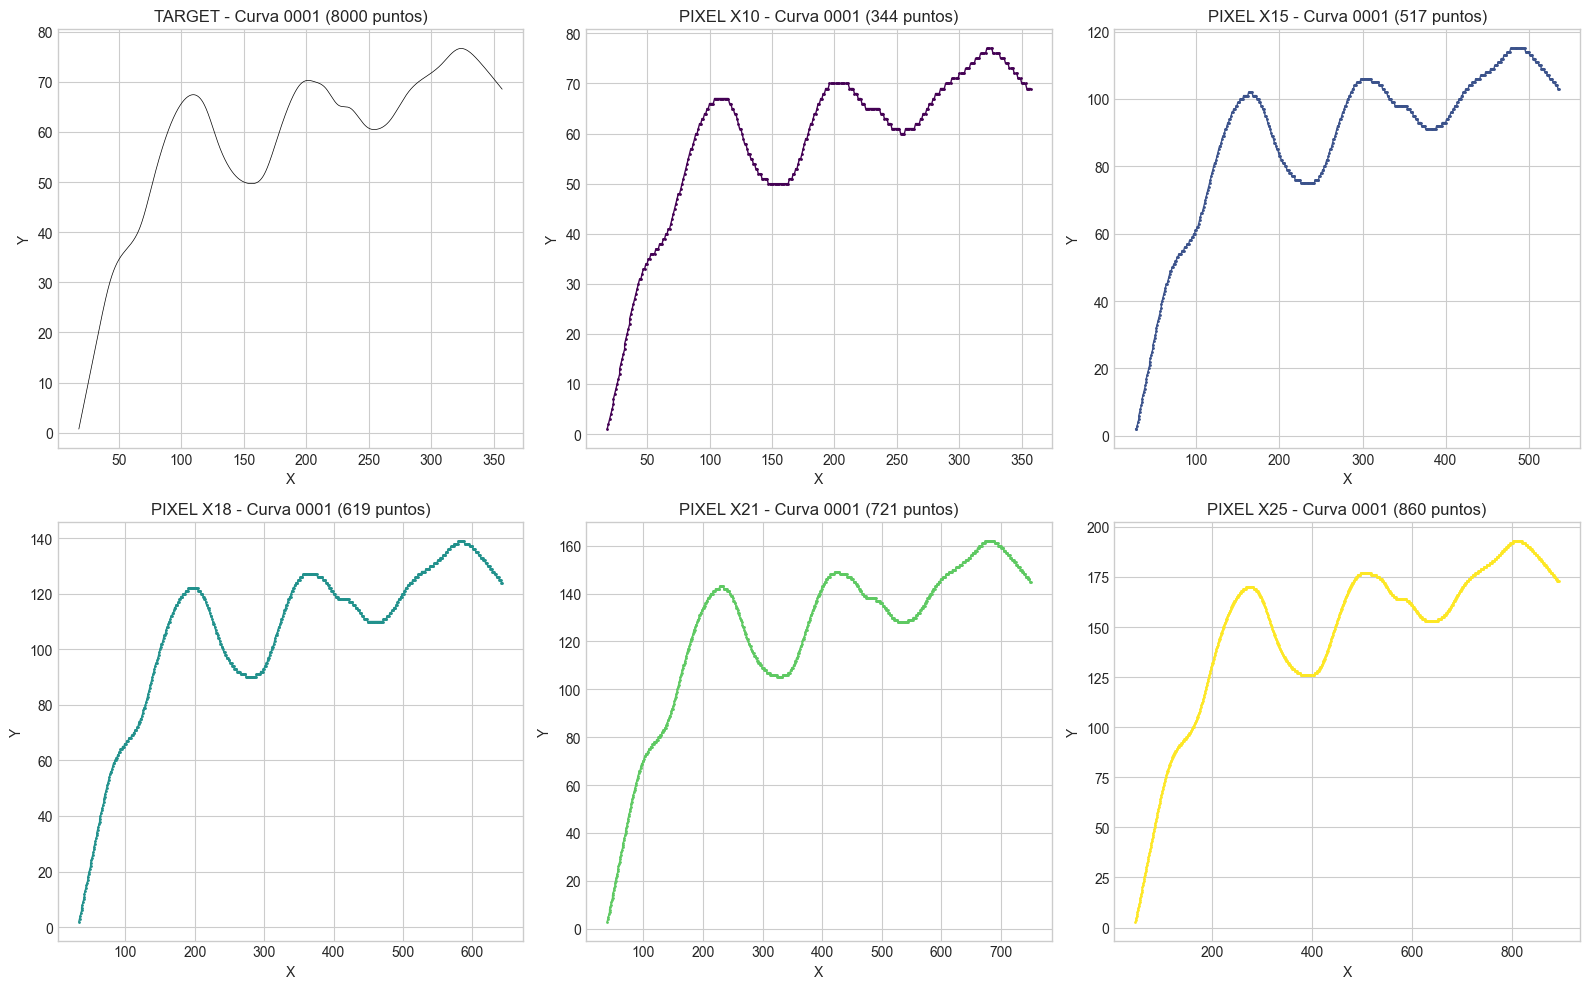

In [23]:
# Visualizacion de una curva ejemplo en target vs todas las variantes pixel
example_curve = 1

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Curva target
t_x, t_y = target_data[example_curve]['x'], target_data[example_curve]['y']
axes[0, 0].plot(t_x, t_y, linewidth=0.5, color='black')
axes[0, 0].set_title(f'TARGET - Curva {example_curve:04d} ({len(t_x)} puntos)')
axes[0, 0].set_xlabel('X')
axes[0, 0].set_ylabel('Y')

# Curvas pixel
colors = plt.cm.viridis(np.linspace(0, 1, len(x_values)))
for idx, x_val in enumerate(x_values):
    row = (idx + 1) // 3
    col = (idx + 1) % 3
    p_x, p_y = pixel_data[x_val][example_curve]['x'], pixel_data[x_val][example_curve]['y']
    axes[row, col].plot(p_x, p_y, linewidth=1, color=colors[idx], marker='.', markersize=2)
    axes[row, col].set_title(f'PIXEL X{x_val} - Curva {example_curve:04d} ({len(p_x)} puntos)')
    axes[row, col].set_xlabel('X')
    axes[row, col].set_ylabel('Y')

plt.tight_layout()
plt.savefig('comparativa_target_pixel.png', dpi=150, bbox_inches='tight')
plt.show()

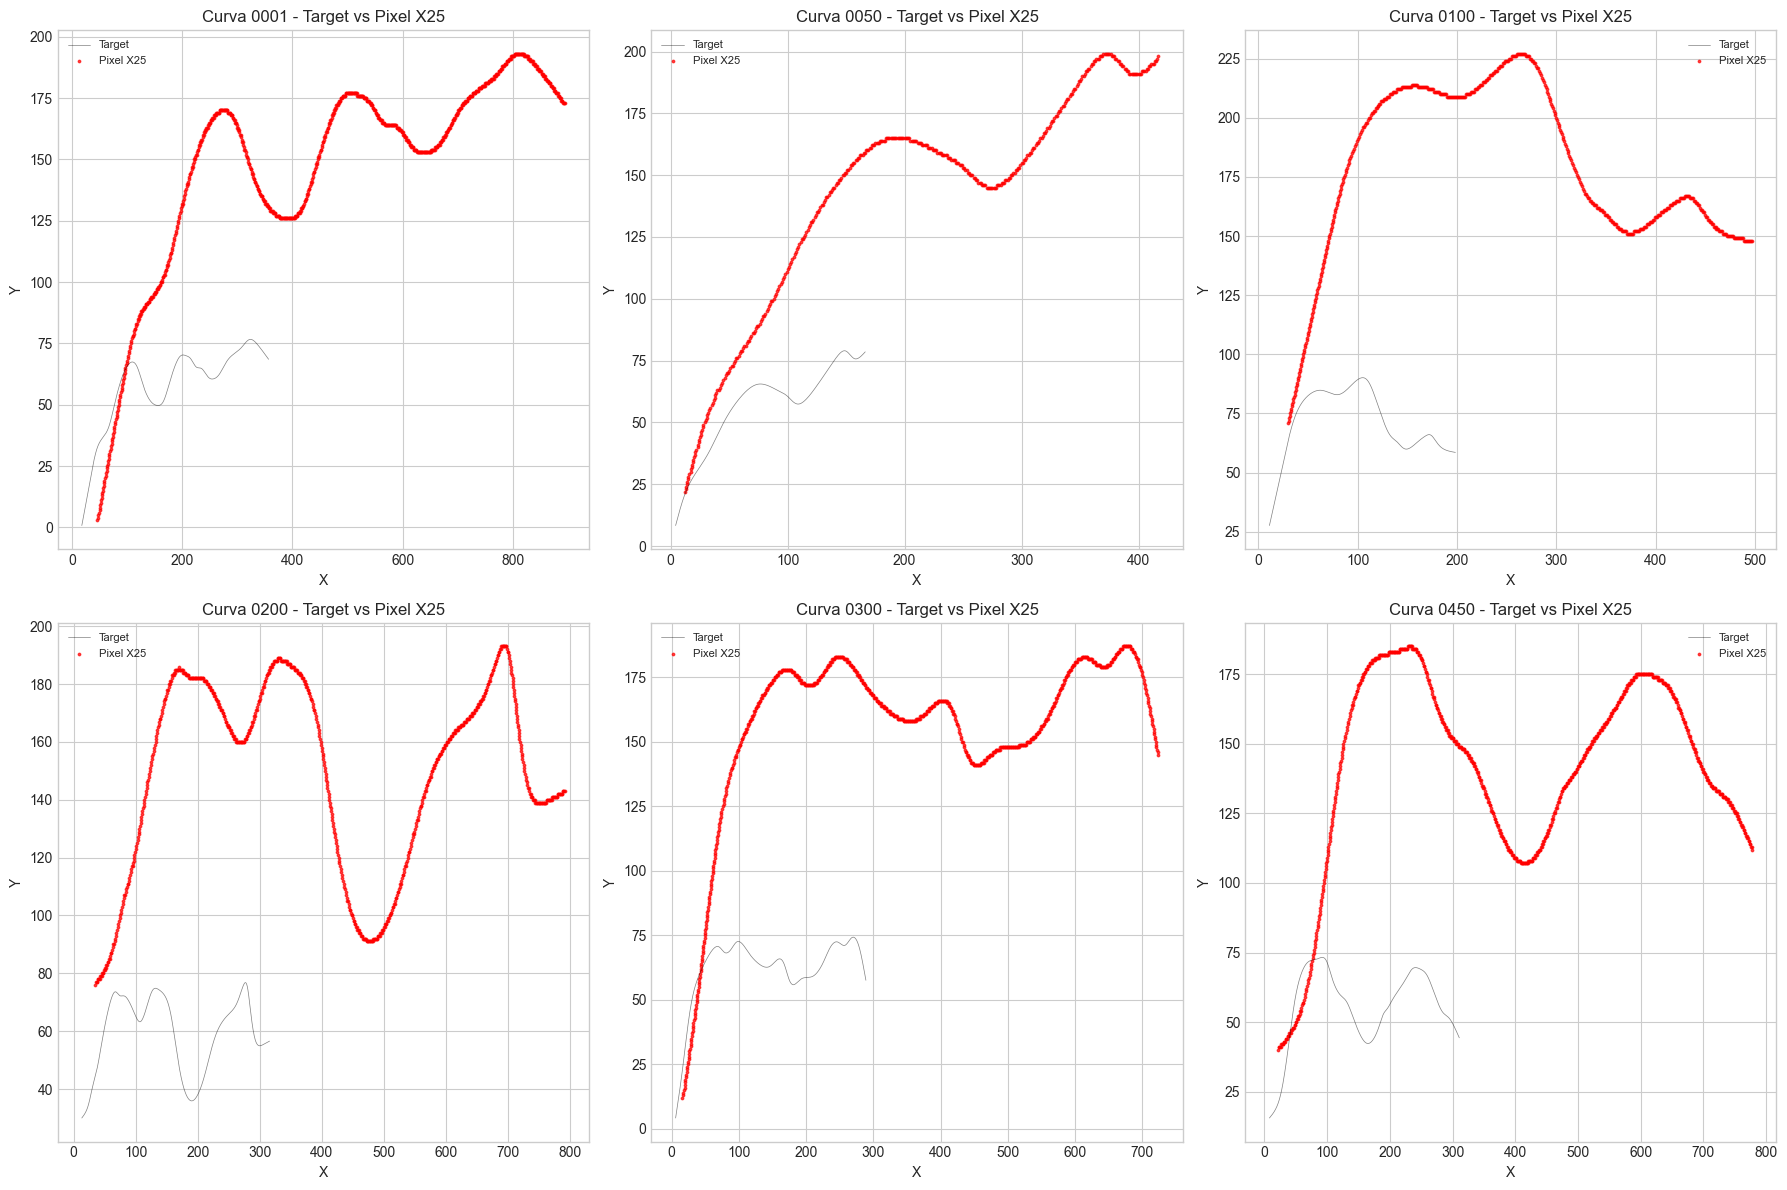

In [24]:
# Superposicion de todas las variantes
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 6 curvas de ejemplo diferentes
example_curves = [1, 50, 100, 200, 300, 450]

for idx, curve_id in enumerate(example_curves):
    ax = axes[idx // 3, idx % 3]
    
    # Target
    t_x, t_y = target_data[curve_id]['x'], target_data[curve_id]['y']
    ax.plot(t_x, t_y, linewidth=0.5, color='black', label='Target', alpha=0.5)
    
    # Pixel de mayor resolucion (X25)
    p_x, p_y = pixel_data[25][curve_id]['x'], pixel_data[25][curve_id]['y']
    ax.scatter(p_x, p_y, s=3, color='red', alpha=0.7, label='Pixel X25')
    
    ax.set_title(f'Curva {curve_id:04d} - Target vs Pixel X25')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('superposicion_curvas.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Conclusiones del Analisis Estadistico

### Hallazgos Principales:

1. **Curvas Target:**
   - Todas tienen exactamente 8,000 puntos
   - Coordenadas X: rango tipico de ~10-360 unidades
   - Coordenadas Y: rango tipico de ~0-200 unidades
   - Alta precision numerica (15+ decimales)

2. **Curvas Pixel:**
   - Numero de puntos escala linealmente con parametro X
   - X10: ~4% de los puntos target
   - X25: ~8% de los puntos target
   - Coordenadas discretizadas (valores enteros)

3. **Relacion Parametro X:**
   - Formula aproximada: Puntos = 35.1 * X - 63.9
   - R^2 muy alto indicando relacion lineal fuerte
   - X representa un factor de escala/resolucion

4. **Distribuciones:**
   - No siguen distribucion normal (como era de esperar para curvas parametricas)
   - Correlacion X-Y varia significativamente entre curvas
   - Rangos de coordenadas mantienen proporciones similares entre variantes